## Potrzebne biblioteki

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim

import torchvision
from torchvision import transforms, datasets

## Wybór urządzenia

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## Zbiór danych

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
dataset = datasets.ImageFolder("trafic_32", transform=transform)
# dataloader = data.DataLoader(dataset, batch_size=128, shuffle=True)

## Rozkład próbek w klasach

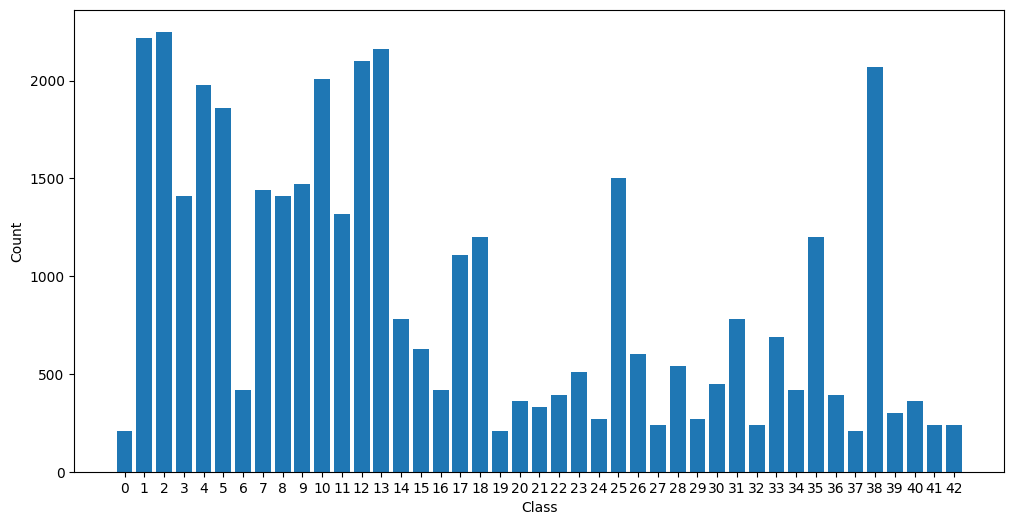

In [4]:
class_counts = Counter(dataset.targets)

classes = list(class_counts.keys())
counts = [class_counts[c] for c in classes]

plt.figure(figsize=(12, 6))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(classes)
plt.show()

## Ważenie próbek

In [5]:
counts = np.bincount(dataset.targets)
weights = 1.0 / counts

sample_weights = [weights[t] for t in dataset.targets]

sampler = data.WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

dataloader = data.DataLoader(dataset, batch_size=128, sampler=sampler)

## Architektura VAEGAN

In [6]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(input_dim, hidden_dim, 4, 2, 1),  # 16x16
            nn.LeakyReLU(0.2),
            nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1),  # 8x8
            nn.BatchNorm2d(hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1),  # 4x4
            nn.BatchNorm2d(hidden_dim * 4),
            nn.LeakyReLU(0.2),
        )

        self.fc_mean = nn.Linear(hidden_dim * 4 * 4 * 4, latent_dim)
        self.fc_var = nn.Linear(hidden_dim * 4 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)

        mean = self.fc_mean(x)
        var = self.fc_var(x)
        return mean, var


def reparameterization(mean, var):
    z = mean + torch.exp(0.5 * var) * torch.randn_like(mean)
    return z

In [7]:
class Discriminator(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Discriminator, self).__init__()

        self.conv_1 = nn.Conv2d(input_dim, hidden_dim, 4, 2, 1, bias=False)

        self.conv_2 = nn.Conv2d(hidden_dim, hidden_dim * 2, 4, 2, 1, bias=False)
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.Conv2d(hidden_dim * 2, hidden_dim * 4, 4, 2, 1, bias=False)
        self.bn_3 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_out = nn.Conv2d(hidden_dim * 4, 1, 4, 1, 0, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        x = self.act(self.conv_1(x))
        x = self.act(self.bn_2(self.conv_2(x)))
        x = self.act(self.bn_3(self.conv_3(x)))

        x = torch.sigmoid(self.conv_out(x))
        return torch.flatten(x)


class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Generator, self).__init__()

        self.conv_1 = nn.ConvTranspose2d(
            latent_dim, hidden_dim * 4, 4, 1, 0, bias=False
        )
        self.bn_1 = nn.BatchNorm2d(hidden_dim * 4)

        self.conv_2 = nn.ConvTranspose2d(
            hidden_dim * 4, hidden_dim * 2, 4, 2, 1, bias=False
        )
        self.bn_2 = nn.BatchNorm2d(hidden_dim * 2)

        self.conv_3 = nn.ConvTranspose2d(
            hidden_dim * 2, hidden_dim, 4, 2, 1, bias=False
        )
        self.bn_3 = nn.BatchNorm2d(hidden_dim)

        self.conv_4 = nn.ConvTranspose2d(hidden_dim, output_dim, 4, 2, 1, bias=False)

        self.act = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.act(self.bn_1(self.conv_1(x)))
        h = self.act(self.bn_2(self.conv_2(h)))
        h = self.act(self.bn_3(self.conv_3(h)))

        x_hat = torch.sigmoid(self.conv_4(h))
        return x_hat

## Inicjalizacja sieci

In [8]:
latent_dim = 128
hidden_dim = 64
channels = 3
num_classes = len(dataset.class_to_idx)

encoder = Encoder(input_dim=channels, latent_dim=latent_dim, hidden_dim=hidden_dim).to(
    device
)
generator = Generator(
    latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=channels
).to(device)

discriminator = Discriminator(input_dim=channels, hidden_dim=hidden_dim).to(device)

encoder_optimizer = optim.Adam(encoder.parameters(), lr=0.0002, betas=(0.5, 0.999))
generator_optimizer = torch.optim.Adam(
    generator.parameters(), lr=0.0004, betas=(0.5, 0.999)
)
generator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=generator_optimizer, gamma=0.99
)
discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999)
)
discriminator_scheduler = optim.lr_scheduler.ExponentialLR(
    optimizer=discriminator_optimizer, gamma=0.99
)

criterion = nn.BCELoss()
criterion_vae = nn.MSELoss()

## Pętla treningowa

Epoch: 0, discrimiantor fake error: 0.481, discriminator real acc: 0.511


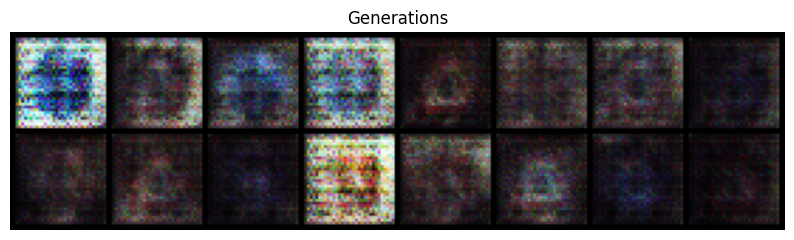

Epoch: 1, discrimiantor fake error: 0.477, discriminator real acc: 0.517
Epoch: 2, discrimiantor fake error: 0.461, discriminator real acc: 0.532
Epoch: 3, discrimiantor fake error: 0.449, discriminator real acc: 0.543
Epoch: 4, discrimiantor fake error: 0.441, discriminator real acc: 0.552
Epoch: 5, discrimiantor fake error: 0.425, discriminator real acc: 0.568
Epoch: 6, discrimiantor fake error: 0.4, discriminator real acc: 0.594
Epoch: 7, discrimiantor fake error: 0.377, discriminator real acc: 0.617
Epoch: 8, discrimiantor fake error: 0.357, discriminator real acc: 0.636
Epoch: 9, discrimiantor fake error: 0.343, discriminator real acc: 0.65
Epoch: 10, discrimiantor fake error: 0.324, discriminator real acc: 0.671


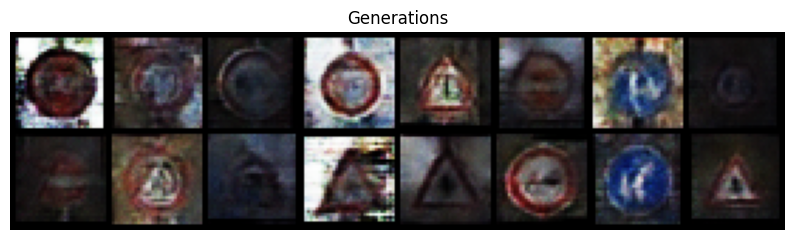

Epoch: 11, discrimiantor fake error: 0.313, discriminator real acc: 0.684
Epoch: 12, discrimiantor fake error: 0.297, discriminator real acc: 0.697
Epoch: 13, discrimiantor fake error: 0.28, discriminator real acc: 0.714
Epoch: 14, discrimiantor fake error: 0.268, discriminator real acc: 0.728
Epoch: 15, discrimiantor fake error: 0.254, discriminator real acc: 0.74
Epoch: 16, discrimiantor fake error: 0.246, discriminator real acc: 0.749
Epoch: 17, discrimiantor fake error: 0.235, discriminator real acc: 0.761
Epoch: 18, discrimiantor fake error: 0.228, discriminator real acc: 0.769
Epoch: 19, discrimiantor fake error: 0.211, discriminator real acc: 0.784
Epoch: 20, discrimiantor fake error: 0.212, discriminator real acc: 0.786


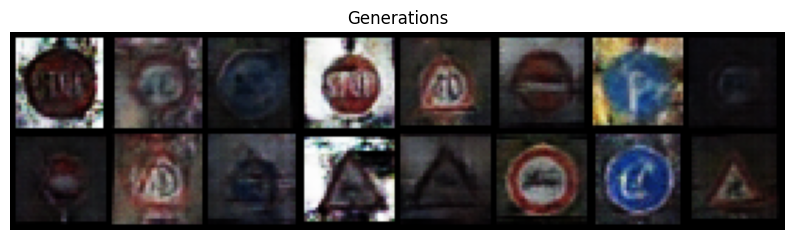

Epoch: 21, discrimiantor fake error: 0.197, discriminator real acc: 0.802
Epoch: 22, discrimiantor fake error: 0.193, discriminator real acc: 0.806
Epoch: 23, discrimiantor fake error: 0.184, discriminator real acc: 0.812
Epoch: 24, discrimiantor fake error: 0.183, discriminator real acc: 0.815
Epoch: 25, discrimiantor fake error: 0.161, discriminator real acc: 0.837
Epoch: 26, discrimiantor fake error: 0.169, discriminator real acc: 0.829
Epoch: 27, discrimiantor fake error: 0.158, discriminator real acc: 0.84
Epoch: 28, discrimiantor fake error: 0.161, discriminator real acc: 0.839
Epoch: 29, discrimiantor fake error: 0.148, discriminator real acc: 0.851
Epoch: 30, discrimiantor fake error: 0.149, discriminator real acc: 0.849


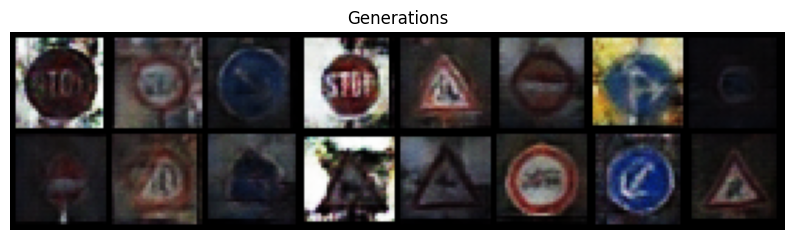

KeyboardInterrupt: 

In [9]:
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

G_losses = []
D_losses = []
num_epochs = 100
for epoch in range(num_epochs):
    discriminator_fake_acc = []
    discriminator_real_acc = []
    for i, data in enumerate(dataloader, 0):
        ####################
        # Update D network #
        ####################

        ## Train with all-real batch
        discriminator_optimizer.zero_grad()

        real_images = data[0].to(device)
        b_size = real_images.size(0)
        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(real_images).view(-1)
        error_discriminator_real = criterion(output, label)
        discriminator_real_acc.append(output.mean().item())

        ## Train with all-fake batch
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)

        fake_images = generator(noise)
        label_fake = torch.zeros((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images.detach()).view(-1)
        error_discriminator_fake = criterion(output, label_fake)
        discriminator_fake_acc.append(output.mean().item())

        # VAE
        mean, var = encoder(real_images)
        z = reparameterization(mean, var)
        vae_images = generator(z.view(b_size, latent_dim, 1, 1))
        output_vae = discriminator(vae_images.detach()).view(-1)
        error_discriminator_vae = criterion(output_vae, label_fake)

        error_discriminator = (
            error_discriminator_real
            + (error_discriminator_fake + error_discriminator_vae) / 2
        )
        error_discriminator.backward()

        discriminator_optimizer.step()

        ####################
        # Update G network #
        ####################
        generator_optimizer.zero_grad()
        encoder_optimizer.zero_grad()

        label = torch.ones((b_size,), dtype=torch.float, device=device)

        output = discriminator(fake_images).view(-1)
        error_generator = criterion(output, label)

        output_vae = discriminator(vae_images).view(-1)
        error_generator_vae = criterion(output_vae, label)
        error_vae = criterion_vae(vae_images, real_images)
        error_kld = -0.5 * torch.sum(1 + var - mean.pow(2) - var.exp()) / b_size

        error_generator += error_generator_vae + error_vae + error_kld
        error_generator.backward()

        generator_optimizer.step()
        encoder_optimizer.step()

        G_losses.append(error_generator.item())
        D_losses.append(error_discriminator.item())

    print(
        f"Epoch: {epoch}, discrimiantor fake error: {np.mean(discriminator_fake_acc):.3}, discriminator real acc: {np.mean(discriminator_real_acc):.3}"
    )
    generator_scheduler.step()
    discriminator_scheduler.step()
    if epoch % 10 == 0:
        with torch.no_grad():
            fake = generator(fixed_noise).detach().cpu()
        grid = torchvision.utils.make_grid(fake)
        grid = grid.permute(1, 2, 0)
        plt.figure(figsize=(10, 10))
        plt.title(f"Generations")
        plt.imshow(grid)
        plt.axis("off")
        plt.show()